# Practical L8

<div class="page-subtitle">
Interactive Exploration and Data-Driven Cartography
</div>

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HendrikWulf/sds210-jb/blob/main/book/10_L08_data-visualisation/07_practical_L8.ipynb)

---


```{admonition} A Note on Visualisation
:class: important

**Welcome to the art of spatial data science.** Up until now, our focus has been on data wrangling, topological queries, and statistical calculations. In this practical, you step into the role of a web cartographer and data artist. You will build an interactive web app to explore global hydrological basins, and then use your interactive map to select a region of interest to design a striking, high-resolution "dark mode" river map.
```

## Learning objectives

After completing this practical, you will be able to:

  * build multi-layered interactive web apps using GeoPandas `.explore()` and Folium.
  * utilize the `mask` parameter in GeoPandas to efficiently clip large vector datasets upon reading.
  * engineer visual variables by mathematically scaling raw attributes (catchment area) to visual properties (line thickness).
  * apply custom cartographic styling in Matplotlib to generate presentation-ready data art.

---

## Practical storyline

You have been hired as a geospatial visualization specialist for a major international water conservation NGO. They are preparing a flagship annual digital report on global freshwater ecosystems.

Your task is twofold. First, you must build an interactive "Basin Explorer" web app that allows the research team to view HydroSHEDS basins at varying levels of detail (Levels 1 to 3). Second, once the team uses your web app to select a specific basin of interest, you will run an automated cartography pipeline to generate a stunning, high-resolution "dark mode" atlas of that basin's river network, where the physical width of the rivers dynamically scales based on their upstream catchment area.

---

## Part 0 – The Data Intake Helper

For this practical, we are using the **HydroRIVERS** dataset (filtered) [831 MB] and the **HydroSHEDS** basin boundaries (Levels 1 [27 MB], 2 [36 MB], and 3 [47 MB]). As these datasets are larger than usual, they have been stored outside GitLab. For convenience, they are hosted on Google Drive, where we can use the `gdown` library to download them directly into our local environment. Alternatively, you can download the datasets manually using this [link](https://drive.google.com/drive/folders/1FiMjQdKq4xt31cYXSCHPhi5-0jriD3If?usp=sharing). The data can also be found on the university course server under the `course/sds210/data/L08/`.

### Tasks

1.  Run the cell below to download the required datasets to your local `data` folder.

In [4]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

# Install packages (if needed)
# !pip install gdown
import gdown

# !pip install cmcrameri
import cmcrameri.cm as cmc

# Create data directory
data_folder = "data"
os.makedirs(data_folder, exist_ok=True)

# Dictionary of file IDs and their output names
datasets = {
    "hydrorivers_100.gpkg": "1fbJewilJnHkEQjNxEbhid0EGVH1X2Evi",
    "hydrosheds_basins_level_01.gpkg": "1wReA_w83eO8sR-4Ma_j-JvtjoSeCU5Z0",
    "hydrosheds_basins_level_02.gpkg": "1uA4qvCIv0egR7698WkI8oUIidjmPLt_n",
    "hydrosheds_basins_level_03.gpkg": "1mJcFlzCEt-K60DoVX8BE1gmEFhfTDux3",
}

for filename, file_id in datasets.items():
    filepath = os.path.join(data_folder, filename)
    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, filepath, quiet=False)
    else:
        print(f"{filename} already exists.")

rivers_fp = os.path.join(data_folder, "hydrorivers_100.gpkg")
basins_l1_fp = os.path.join(data_folder, "hydrosheds_basins_level_01.gpkg")
basins_l2_fp = os.path.join(data_folder, "hydrosheds_basins_level_02.gpkg")
basins_l3_fp = os.path.join(data_folder, "hydrosheds_basins_level_03.gpkg")

Downloading...
From (original): https://drive.google.com/uc?id=1fbJewilJnHkEQjNxEbhid0EGVH1X2Evi
From (redirected): https://drive.google.com/uc?id=1fbJewilJnHkEQjNxEbhid0EGVH1X2Evi&confirm=t&uuid=d752344f-0abb-4bbc-b9cc-7654047b08b3
To: /Users/jonasbezencon/Documents/Studies/UZH/exchange_programm/semester_6/programming_with_spatial_data/course/data/hydrorivers_100.gpkg
100%|██████████| 831M/831M [00:21<00:00, 39.4MB/s] 


Downloading...
From: https://drive.google.com/uc?id=1wReA_w83eO8sR-4Ma_j-JvtjoSeCU5Z0
To: /Users/jonasbezencon/Documents/Studies/UZH/exchange_programm/semester_6/programming_with_spatial_data/course/data/hydrosheds_basins_level_01.gpkg
100%|██████████| 26.7M/26.7M [00:00<00:00, 42.3MB/s]


Downloading...
From: https://drive.google.com/uc?id=1uA4qvCIv0egR7698WkI8oUIidjmPLt_n
To: /Users/jonasbezencon/Documents/Studies/UZH/exchange_programm/semester_6/programming_with_spatial_data/course/data/hydrosheds_basins_level_02.gpkg
100%|██████████| 35.6M/35.6M [00:01<00:00, 31.0MB/s]


Downloading...
From: https://drive.google.com/uc?id=1mJcFlzCEt-K60DoVX8BE1gmEFhfTDux3
To: /Users/jonasbezencon/Documents/Studies/UZH/exchange_programm/semester_6/programming_with_spatial_data/course/data/hydrosheds_basins_level_03.gpkg
100%|██████████| 46.9M/46.9M [00:01<00:00, 37.1MB/s]


---

## Part 1 – The Basin Explorer Web App

Before we load the massive river dataset, we need to decide which basin to map. We will build an interactive map featuring the three HydroSHEDS basin layers. We will format the tooltips so the researchers can easily read the catchment areas and retrieve the unique Basin ID.

### Tasks

1.  **Load the Basins:** Read the Level 1, 2, and 3 basin GeoPackages into GeoDataFrames (`l1`, `l2`, `l3`). Ensure they are all in `EPSG:4326`.
2.  **Format the Tooltip:** The `UP_AREA` column contains the upstream area in square kilometers. Create a new column in each GeoDataFrame called `Tooltip_Area` that formats this number for human readability (e.g., `Area: 4'256'308 km²`).
3.  **Initialize the Web App:** Create a `folium.Map` centered globally (e.g., `location=[20, 0]`) with a `zoom_start` of 3. Use a dark basemap like `"CartoDB DarkMatter"`.
4.  **Add the Layers:** Use the [`.explore()`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.explore.html#geopandas.GeoDataFrame.explore) method on each GeoDataFrame to add them to your map.
      * Color the polygons based on `UP_AREA`. Choose suitable colormaps from [matplotlib](https://matplotlib.org/stable/users/explain/colors/colormaps.html) and [crameri](https://www.fabiocrameri.ch/colourmaps/).
      * Set the fill transparency high enough to see the basemap (e.g. `alpha=0.4`).
      * Set the tooltips to show the `HYBAS_ID` and your newly formatted `Tooltip_Area`.
      * Turn `show=False` for Levels 2 and 3 so the map isn't cluttered on load.
5.  **Layer Control:** Add a `folium.LayerControl()` and display your app. Explore the map and pick a basin you find interesting! Write down its `HYBAS_ID`.

In [1]:
# Write your code here
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import cmcrameri.cm as cmc
from IPython.display import display


l1 = gpd.read_file("data/hydrosheds_basins_level_01.gpkg").to_crs("EPSG:4326")
l2 = gpd.read_file("data/hydrosheds_basins_level_02.gpkg").to_crs("EPSG:4326")
l3 = gpd.read_file("data/hydrosheds_basins_level_03.gpkg").to_crs("EPSG:4326")

def format_area(x):
    return f"Area: {int(x):,} km²".replace(",", "'")

l1["Tooltip_Area"] = l1["UP_AREA"].apply(format_area)
l2["Tooltip_Area"] = l2["UP_AREA"].apply(format_area)
l3["Tooltip_Area"] = l3["UP_AREA"].apply(format_area)

map = folium.Map(
    location=[20, 0],
    zoom_start=3,
    tiles="CartoDB DarkMatter"
)

l1.explore(
    m=map,
    column="UP_AREA",
    cmap="viridis",
    alpha=0.4,
    tooltip=["HYBAS_ID", "Tooltip_Area"],
    name="Basin Level 1",
    legend=True
)

l2.explore(
    m=map,
    column="UP_AREA",
    cmap="plasma",
    alpha=0.4,
    tooltip=["HYBAS_ID", "Tooltip_Area"],
    name="Basin Level 2",
    show=False
)

l3.explore(
    m=map,
    column="UP_AREA",
    cmap="cividis",
    alpha=0.4,
    tooltip=["HYBAS_ID", "Tooltip_Area"],
    name="Basin Level 3",
    show=False
)

folium.LayerControl(collapsed=False).add_to(map)

map.save("map.html")

---

## Part 2 – Extracting the River Network

Now that you have explored the basins, it is time to load the actual river data. Instead of loading the entire world (which would crash your computer), we will use your chosen basin as a spatial `mask`.

### Tasks

1.  **Define Your Basin:** Create a variable `target_basin_id` and assign it the `HYBAS_ID` of the basin you selected in Part 1 (e.g., the Amazon basin in South America, or the Congo basin in Africa).
2.  **Filter the Boundary:** Filter the appropriate basin GeoDataFrame (L1, L2, or L3 depending on where you got your ID) to keep only the row matching your `target_basin_id`. Save this as `selected_basin`.
3.  **Mask and Load:** Use [`gpd.read_file()`](https://geopandas.org/en/stable/docs/reference/api/geopandas.read_file.html#geopandas.read_file) to load the `rivers_fp`. Pass your `selected_basin` GeoDataFrame to the `mask` parameter. Save the result as `river_gdf`.

In [22]:
# Write your code here

target_basin_id = 2030020320

selected_basin = l3[
    l3["HYBAS_ID"] == target_basin_id
]

river_gdf = gpd.read_file(
    "data/hydrorivers_100.gpkg",
    mask=selected_basin
)

river_gdf = river_gdf.to_crs("EPSG:4326")

print(l3.head())
print(l3[l3["HYBAS_ID"] == 2030020320])

                     id  COAST  DIST_MAIN  DIST_SINK  ENDO    HYBAS_ID  \
0  0000000000000000000c      1        0.0        0.0     0  1030000010   
1  00000000000000000033      1        0.0        0.0     0  8030000010   
2  00000000000000000044      1        0.0        0.0     0  4030000010   
3  00000000000000000071      1        0.0        0.0     0  5030000010   
4  000000000000000000b6      1        0.0        0.0     0  2030000010   

     MAIN_BAS  NEXT_DOWN   NEXT_SINK  ORDER  PFAF_ID  SORT  SUB_AREA  \
0  1030000010          0  1030000010      0      111     1  236343.2   
1  8030000010          0  8030000010      0      811     1  582683.3   
2  4030000010          0  4030000010      0      421     1  105274.5   
3  5030000010          0  5030000010      0      511     1  440720.2   
4  2030000010          0  2030000010      0      211     1  328692.9   

    UP_AREA                                           geometry  \
0  236343.2  MULTIPOLYGON (((37.1625 21.20833, 37.15792 

---

## Part 3 – Engineering Visual Variables

If we plot the rivers now, they will all be exactly the same thickness. A tiny upstream tributary will look identical to the massive main river channel.

To fix this, we need to map the data to a visual variable. We will scale the upstream catchment area (`UPLAND_SKM`) into a visual line width ranging between 0.2 and 2.0.

### Tasks

1.  **Define Bounds:** Create variables: `original_min = 300`, `original_max = 50000` (adjust this upper limit depending on how massive your chosen basin is!), `target_min = 0.2`, and `target_max = 2.0`.
2.  **Scale the Data:** Calculate the scaled fraction: `(river_gdf['UPLAND_SKM'] - original_min) / (original_max - original_min)`.
3.  **Calculate the Width:** Create a new column `river_gdf['width']`. Apply [`.clip(0, 1)`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.clip.html#geopandas.GeoSeries.clip) to your scaled fraction to prevent massive outliers from breaking the map, then multiply it by `(target_max - target_min)` and add `target_min`.
4.  **Sort the Data:** Sort your dataframe by `UPLAND_SKM` (ascending). This guarantees that the thickest, largest rivers are drawn *last* (on top of the smaller streams) so they stand out boldly.

<!-- end list -->

In [23]:
# Write your code here

original_min = 300
original_max = 50000
target_min = 0.2
target_max = 2.0

scaled_fraction = (river_gdf['UPLAND_SKM'] - original_min) / (original_max - original_min)

river_gdf["width"] = scaled_fraction.clip(0,1) * (target_max - target_min) + target_min

river_gdf = river_gdf.sort_values(by="width", ascending=True)

print(river_gdf.is_empty.sum())
print(river_gdf.isna().sum())
print(river_gdf.total_bounds)
print(river_gdf.geometry.is_valid.value_counts())
print(river_gdf.geometry.is_empty.value_counts())
print(river_gdf.geometry.head())
print(selected_basin.crs)
print(river_gdf.crs)
print(selected_basin.total_bounds)
print(river_gdf.total_bounds)

0
HYRIV_ID      0
NEXT_DOWN     0
MAIN_RIV      0
LENGTH_KM     0
DIST_DN_KM    0
DIST_UP_KM    0
CATCH_SKM     0
UPLAND_SKM    0
ENDORHEIC     0
DIS_AV_CMS    0
ORD_STRA      0
ORD_CLAS      0
ORD_FLOW      0
HYBAS_L12     0
geometry      0
width         0
dtype: int64
[-4.76458333 42.61041667 16.70625    53.82708333]
True    16210
Name: count, dtype: int64
False    16210
Name: count, dtype: int64
16207    MULTILINESTRING ((2.06458 48.70208, 2.07292 48...
49       MULTILINESTRING ((-3.58958 48.07708, -3.58958 ...
48       MULTILINESTRING ((-3.55625 48.04792, -3.55208 ...
47       MULTILINESTRING ((-3.55208 48.04792, -3.54792 ...
46       MULTILINESTRING ((-3.47292 48.06875, -3.47292 ...
Name: geometry, dtype: geometry
EPSG:4326
EPSG:4326
[-5.14647592 42.51666793 16.80833174 54.1960346 ]
[-4.76458333 42.61041667 16.70625    53.82708333]


---

## Part 4 – The Dark Canvas (Data Art)

It is time to generate the final, high-resolution static map for the NGO's report. We will use a dark cartographic theme to simulate a glowing, neon river network.

### Tasks

1.  **Setup Canvas:** Create a `fig, ax` subplot with `figsize=(12, 12)`.
2.  **Paint it Black:** Set the background color of the overall figure using `fig.patch.set_facecolor('black')` and the plot area using `ax.set_facecolor('black')`.
3.  **Plot the Rivers:** Call [`.plot()`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html) on your `river_gdf`.
      * Color each distinct sub-basin by setting `column='MAIN_RIV'` and `categorical=True`.
      * Use a vibrant colormap like `cmap='hsv'` or `cmap='magma'`.
      * **Crucial:** Set `linewidth=river_gdf['width']` so every river segment is drawn with its custom calculated thickness!
4.  **Final Polish:** Add a white title (e.g., "Basin Hydrology") and turn the axis off.

<!-- end list -->

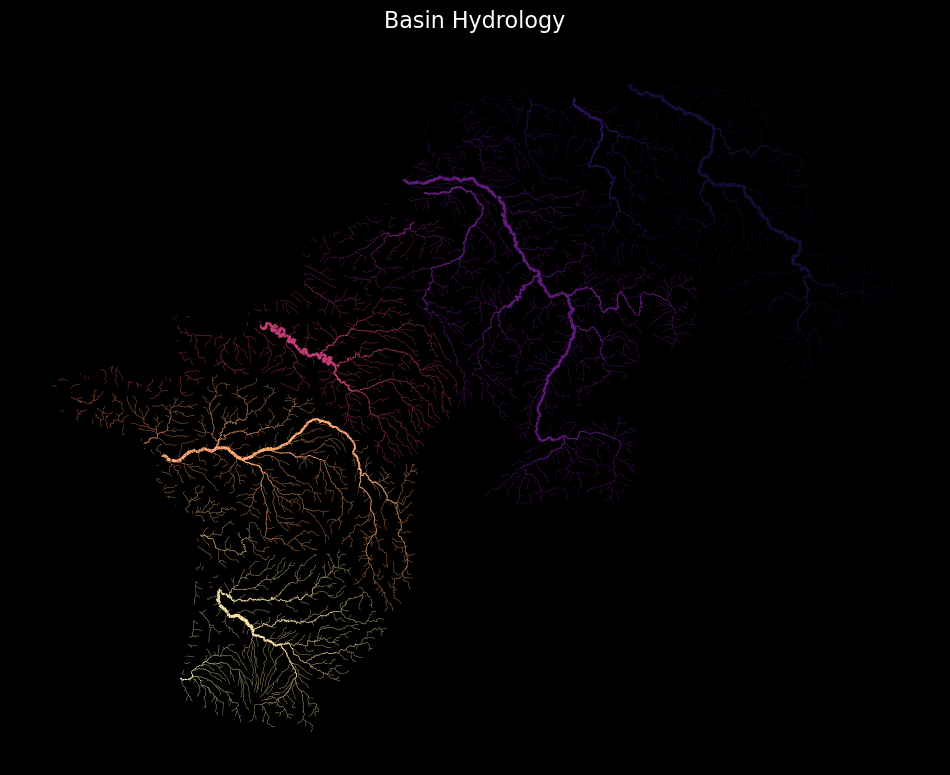

In [24]:
# Write your code here

fig, ax = plt.subplots(figsize=(12, 12))

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

river_gdf.plot(
    ax=ax,
    column="MAIN_RIV",
    categorical=True,
    cmap="magma",
    linewidth=river_gdf["width"].values
)

ax.set_axis_off()

ax.set_title(
    "Basin Hydrology",
    fontsize=16,
    color="white"
)

plt.show()

---

## Reflection

Take a step back and review your workflow. You built a web app to navigate the globe, isolated a massive dataset using spatial masks, and mapped raw statistics into data art. Please answer the following questions briefly:

1.  **Web vs. Static:** Why was it a good idea to use an interactive Folium map to explore the basin *polygons*, but a static Matplotlib map to render the highly detailed river *lines*?
2.  **The Mask Parameter:** Why is passing the `mask` parameter directly into `gpd.read_file()` so much more efficient than loading the entire global river dataset and then clipping it afterward?
3.  **Visual Hierarchy:** In Part 3, why was it mathematically necessary to use `.clip(0, 1)` on our scaled fraction before calculating the final width? What would happen visually to the main river channel if we didn't clip the upper limit?

<!-- end list -->